In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sparsification import *

In [13]:
df = pd.read_csv("cfs.csv")

T, taxa = build_tensor(df)

Tensor shape: (10, 10, 210)


In [14]:
W = collapse_tensor(T, "sum")

Step 1 - Collapsed adjacency matrix W (sum across all quartet layers)
[[ 0.   12.15  3.91 14.91  3.97 13.56  8.76 13.29  6.8   6.65]
 [12.15  0.    4.2  11.87  4.26 11.71  8.97 13.12 10.85  6.87]
 [ 3.91  4.2   0.    3.73 26.87  4.33 10.33  3.56 12.73 14.34]
 [14.91 11.87  3.73  0.    3.79 14.77  7.57 14.59  6.42  6.35]
 [ 3.97  4.26 26.87  3.79  0.    4.39 10.38  3.62 12.54 14.18]
 [13.56 11.71  4.33 14.77  4.39  0.    7.92 13.83  7.26  6.23]
 [ 8.76  8.97 10.33  7.57 10.38  7.92  0.    7.47  9.34 13.26]
 [13.29 13.12  3.56 14.59  3.62 13.83  7.47  0.    8.23  6.29]
 [ 6.8  10.85 12.73  6.42 12.54  7.26  9.34  8.23  0.    9.83]
 [ 6.65  6.87 14.34  6.35 14.18  6.23 13.26  6.29  9.83  0.  ]]


In [15]:
L = compute_laplacian(W)

Step 2 - Graph Laplacian L = D - W
Degree matrix diagonal: [84. 84. 84. 84. 84. 84. 84. 84. 84. 84.]
Laplacian: 
[[ 84.   -12.15  -3.91 -14.91  -3.97 -13.56  -8.76 -13.29  -6.8   -6.65]
 [-12.15  84.    -4.2  -11.87  -4.26 -11.71  -8.97 -13.12 -10.85  -6.87]
 [ -3.91  -4.2   84.    -3.73 -26.87  -4.33 -10.33  -3.56 -12.73 -14.34]
 [-14.91 -11.87  -3.73  84.    -3.79 -14.77  -7.57 -14.59  -6.42  -6.35]
 [ -3.97  -4.26 -26.87  -3.79  84.    -4.39 -10.38  -3.62 -12.54 -14.18]
 [-13.56 -11.71  -4.33 -14.77  -4.39  84.    -7.92 -13.83  -7.26  -6.23]
 [ -8.76  -8.97 -10.33  -7.57 -10.38  -7.92  84.    -7.47  -9.34 -13.26]
 [-13.29 -13.12  -3.56 -14.59  -3.62 -13.83  -7.47  84.    -8.23  -6.29]
 [ -6.8  -10.85 -12.73  -6.42 -12.54  -7.26  -9.34  -8.23  84.    -9.83]
 [ -6.65  -6.87 -14.34  -6.35 -14.18  -6.23 -13.26  -6.29  -9.83  84.  ]]


In [16]:
R = compute_effective_resistance(L)

Step 3 — Effective resistance matrix R
[[0.     0.0208 0.0247 0.0202 0.0246 0.0205 0.0221 0.0206 0.0226 0.023 ]
 [0.0208 0.     0.0243 0.0209 0.0243 0.0209 0.0219 0.0206 0.0216 0.0227]
 [0.0247 0.0243 0.     0.0248 0.018  0.0245 0.0218 0.0248 0.0212 0.0206]
 [0.0202 0.0209 0.0248 0.     0.0248 0.0203 0.0224 0.0203 0.0228 0.0231]
 [0.0246 0.0243 0.018  0.0248 0.     0.0245 0.0218 0.0248 0.0212 0.0207]
 [0.0205 0.0209 0.0245 0.0203 0.0245 0.     0.0222 0.0204 0.0225 0.023 ]
 [0.0221 0.0219 0.0218 0.0224 0.0218 0.0222 0.     0.0224 0.0215 0.0206]
 [0.0206 0.0206 0.0248 0.0203 0.0248 0.0204 0.0224 0.     0.0223 0.0231]
 [0.0226 0.0216 0.0212 0.0228 0.0212 0.0225 0.0215 0.0223 0.     0.0214]
 [0.023  0.0227 0.0206 0.0231 0.0207 0.023  0.0206 0.0231 0.0214 0.    ]]


In [17]:
edge_list = compute_edge_sampling_probabilities(
    W, R, taxa
)

Step 4 - Edge sampling probabilities
Edge         Weight     Eff.Res.   Score      Prob      
t3-t5       26.8700    0.0180     0.4847     0.0539    
t1-t4       14.9100    0.0202     0.3016     0.0335    
t4-t6       14.7700    0.0203     0.2992     0.0332    
t4-t8       14.5900    0.0203     0.2961     0.0329    
t3-t10      14.3400    0.0206     0.2959     0.0329    
t5-t10      14.1800    0.0207     0.2929     0.0325    
t6-t8       13.8300    0.0204     0.2828     0.0314    
t1-t6       13.5600    0.0205     0.2780     0.0309    
t7-t10      13.2600    0.0206     0.2737     0.0304    
t1-t8       13.2900    0.0206     0.2733     0.0304    
t2-t8       13.1200    0.0206     0.2706     0.0301    
t3-t9       12.7300    0.0212     0.2695     0.0299    
t5-t9       12.5400    0.0212     0.2658     0.0295    
t1-t2       12.1500    0.0208     0.2532     0.0281    
t2-t4       11.8700    0.0209     0.2483     0.0276    
t2-t6       11.7100    0.0209     0.2451     0.0272    
t2-t9     

In [18]:
W_sparse = sample_edges(
    edge_list,
    num_samples=20,
    n=len(taxa),
    taxa=taxa,
    seed=42
)

Step 5 - Sparsified adjacency matrix
[[ 0.     21.5932  0.     22.2478  0.      0.      0.     43.7673 19.8828
  19.5924]
 [21.5932  0.      0.     21.5109  0.      0.     20.5623 21.8156  0.
   0.    ]
 [ 0.      0.      0.     18.1212 24.9456  0.      0.      0.      0.
  21.8105]
 [22.2478 21.5109 18.1212  0.      0.      0.     40.1656  0.      0.
   0.    ]
 [ 0.      0.     24.9456  0.      0.      0.     20.6526  0.     21.2294
   0.    ]
 [ 0.      0.      0.      0.      0.      0.      0.     22.0058  0.
  19.5291]
 [ 0.     20.5623  0.     40.1656 20.6526  0.      0.      0.      0.
   0.    ]
 [43.7673 21.8156  0.      0.      0.     22.0058  0.      0.     20.1348
  19.4765]
 [19.8828  0.      0.      0.     21.2294  0.      0.     20.1348  0.
   0.    ]
 [19.5924  0.     21.8105  0.      0.     19.5291  0.     19.4765  0.
   0.    ]]
Original edges: 45
Surviving unique edges: 18
Edges removed: 27
Surviving edges:
  t1 — t2: 21.5932
  t1 — t4: 22.2478
  t1 — t8: 43.7673
  

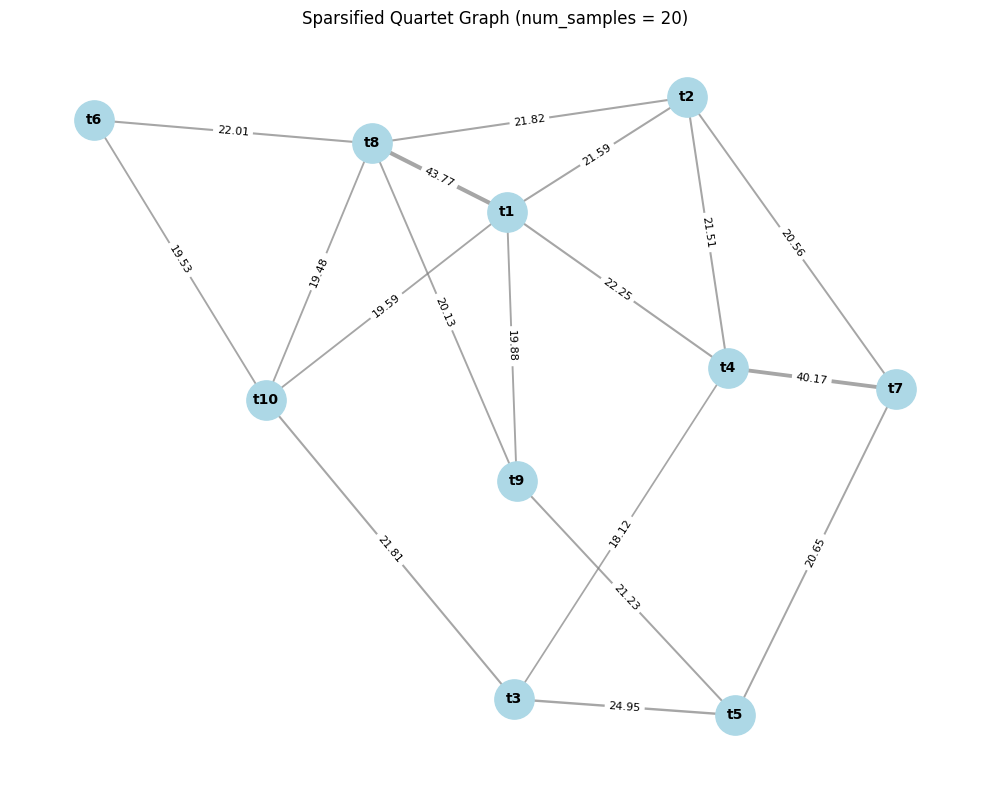

In [19]:
graph = visualize_graph(W_sparse, taxa, 20)